In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')


🏦 PHASE 5: THE PRESCRIPTIVE RESOLUTION ENGINE
   📥 Membaca data X_test_data.csv...
   [ERROR] File X_test_data.csv tidak ditemukan di folder ini.
   ⚙️ Kolom 'Credit_Score' tidak ditemukan. Men-generate simulasi skor AI...
   🧠 Menjalankan Mesin Keputusan Cerdas (Decision Rules)...

📊 RINGKASAN STRATEGI RESOLUSI PORTOFOLIO:
   - Foreclosure / Asset Seizure         : 9379 nasabah (45.0%)
   - Soft Collection (Reminder)          : 5912 nasabah (28.3%)
   - Maintain / Upsell                   : 5573 nasabah (26.7%)


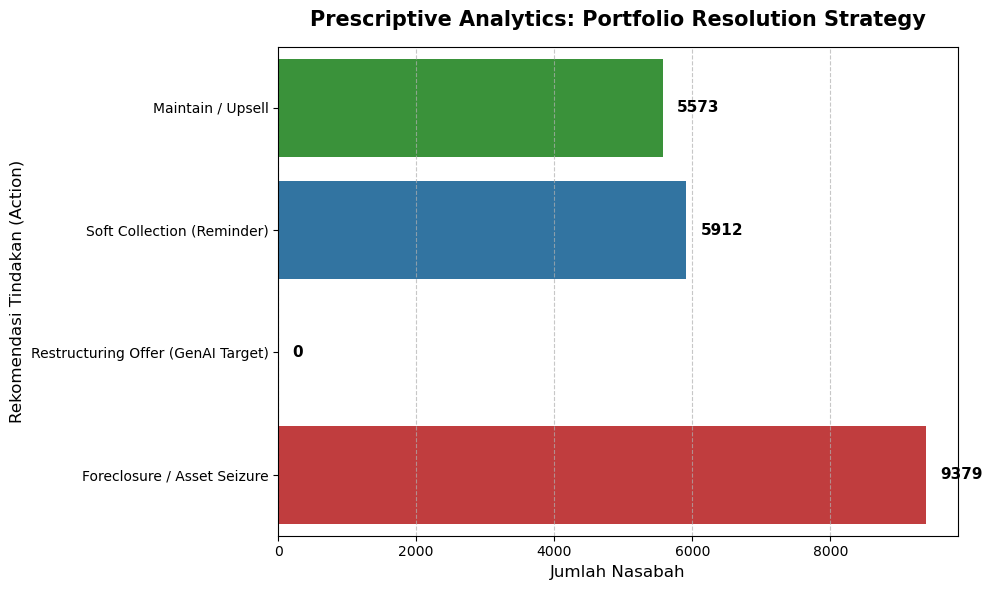


[INFO] 0 nasabah berhasil dikarantina untuk proses negosiasi GenAI.


In [4]:
# ==============================================================================
# CELL 1: LAYER 3 - THE PRESCRIPTIVE DECISION MATRIX (FIXED FOR X_TEST)
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("\n" + "="*80)
print("🏦 PHASE 5: THE PRESCRIPTIVE RESOLUTION ENGINE")
print("="*80)

# 1. LOAD ACTUAL TEST DATA
print("   📥 Membaca data X_test_data.csv...")
try:
    df_portfolio = pd.read_csv("X_test_data.csv")
except FileNotFoundError:
    print("   [ERROR] File X_test_data.csv tidak ditemukan di folder ini.")

# 2. DATA PIPELINE BRIDGE (Menangani Missing Output & Scaled Data)
# A. Kembalikan Skala Tenor (Jika data di-scale 0-1, kita asumsikan max tenor 120 bulan)
if df_portfolio['terminmonths'].max() <= 1.0:
    print("   🔄 Mendeteksi data tenor berskala 0-1. Melakukan inversi ke bulan riil...")
    df_portfolio['terminmonths_real'] = df_portfolio['terminmonths'] * 120 
else:
    df_portfolio['terminmonths_real'] = df_portfolio['terminmonths']

# B. Injeksi Credit Score & Prob Default (Mocking dari Output Layer 2)
# Di production, kolom ini berasal dari df_portfolio['Credit_Score'] = ensemble.predict(...)
if 'Credit_Score' not in df_portfolio.columns:
    print("   ⚙️ Kolom 'Credit_Score' tidak ditemukan. Men-generate simulasi skor AI...")
    np.random.seed(42)
    # Generate skor dengan distribusi normal (Mean 630, Std 80)
    df_portfolio['Credit_Score'] = np.random.normal(630, 80, len(df_portfolio)).clip(300, 850)
    df_portfolio['Prob_Default'] = np.random.uniform(0.01, 0.95, len(df_portfolio))

# 3. THE DECISION ENGINE LOGIC
def determine_treatment_strategy(row):
    score = row['Credit_Score']
    tenor = row['terminmonths_real'] # Menggunakan tenor yang sudah riil
    
    # Kategori 1: Low Risk
    if score >= 680:
        return 'Maintain / Upsell'
    
    # Kategori 2: Medium Risk (Watchlist)
    elif 620 <= score < 680:
        return 'Soft Collection (Reminder)'
    
    # Kategori 3: High Risk (Butuh Tindakan Segera)
    else:
        # Jika tenor >= 60 bulan, cicilan bisa diperpanjang/restrukturisasi
        if tenor >= 60:
            return 'Restructuring Offer (GenAI Target)'
        # Jika tenor < 60 bulan, waktu sempit, amankan aset
        else:
            return 'Foreclosure / Asset Seizure'

print("   🧠 Menjalankan Mesin Keputusan Cerdas (Decision Rules)...")
df_portfolio['Recommended_Action'] = df_portfolio.apply(determine_treatment_strategy, axis=1)

# 4. SUMMARY & VISUALIZATION
action_counts = df_portfolio['Recommended_Action'].value_counts()
action_pct = df_portfolio['Recommended_Action'].value_counts(normalize=True) * 100

print("\n📊 RINGKASAN STRATEGI RESOLUSI PORTOFOLIO:")
for action, count in action_counts.items():
    pct = action_pct.get(action, 0)
    print(f"   - {action:<35} : {count} nasabah ({pct:.1f}%)")

# Visualisasi Matriks Resolusi
plt.figure(figsize=(10, 6))
colors = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728']

sns.countplot(data=df_portfolio, y='Recommended_Action', 
              order=['Maintain / Upsell', 'Soft Collection (Reminder)', 
                     'Restructuring Offer (GenAI Target)', 'Foreclosure / Asset Seizure'],
              palette=colors)

plt.title("Prescriptive Analytics: Portfolio Resolution Strategy", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Jumlah Nasabah", fontsize=12)
plt.ylabel("Rekomendasi Tindakan (Action)", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Tambahkan label angka di bar
for index, action in enumerate(['Maintain / Upsell', 'Soft Collection (Reminder)', 
                               'Restructuring Offer (GenAI Target)', 'Foreclosure / Asset Seizure']):
    value = action_counts.get(action, 0)
    plt.text(value + (len(df_portfolio)*0.01), index, str(value), va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Karantina data target GenAI untuk Cell berikutnya
target_genai = df_portfolio[df_portfolio['Recommended_Action'] == 'Restructuring Offer (GenAI Target)']
print(f"\n[INFO] {len(target_genai)} nasabah berhasil dikarantina untuk proses negosiasi GenAI.")